In [96]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from nltools.stats import regress
from nltools.external import glover_hrf

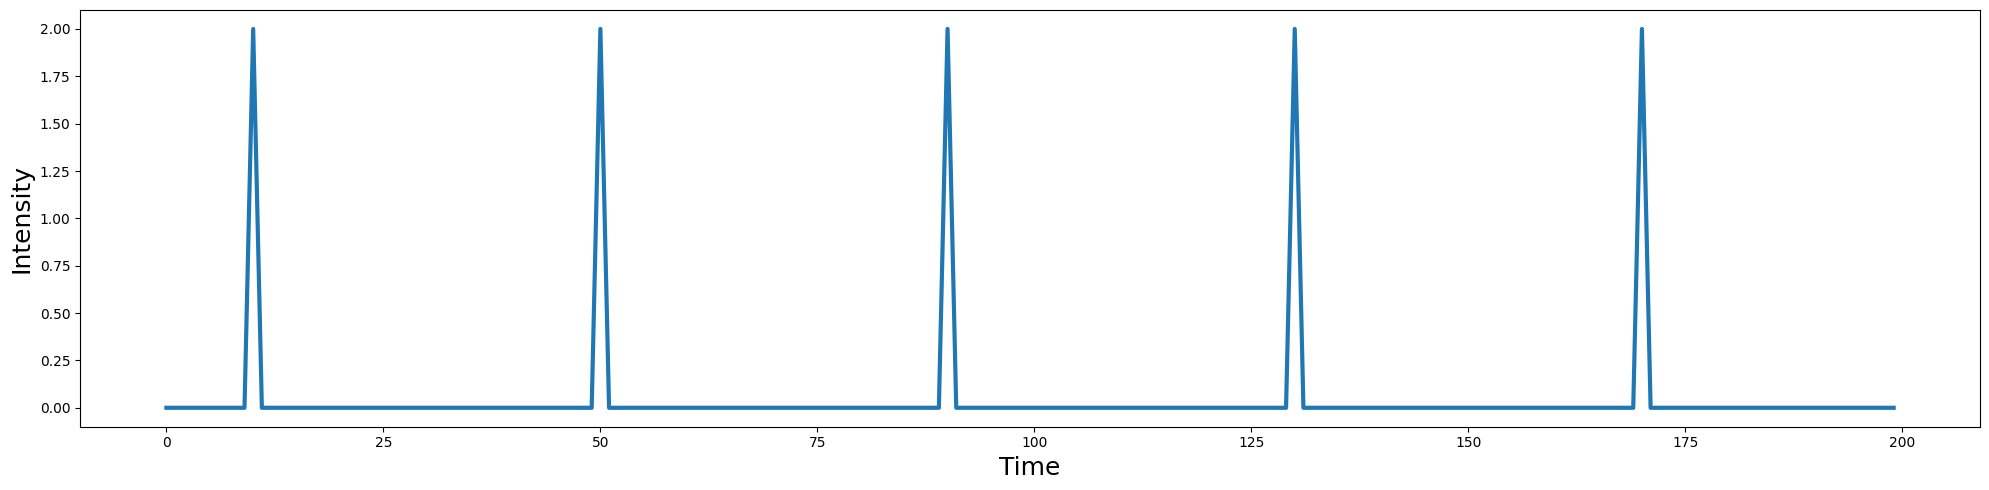

In [97]:
n_tr = 200
n_trial = 5
face = np.zeros(n_tr)
face[np.arange(10, n_tr, int(n_tr/n_trial))] = face_intensity
# face is a numpy array of zeros. First 1 is the 10th index, then every 20th element until index 200
# np arange = range()

#each column is a different signal
def plot_timeseries(data, labels=None, linewidth=3):
    '''Plot a timeseries
    
    Args:
        data: (np.ndarray) signal varying over time, where each column is a different signal.
        labels: (list) labels which need to correspond to the number of columns.
        linewidth: (int) thickness of line
    '''
    plt.figure(figsize=(20,5))
    plt.plot(data, linewidth=linewidth)
    plt.ylabel('Intensity', fontsize=18)
    plt.xlabel('Time', fontsize=18)
    plt.tight_layout()
    if labels is not None:
        if len(labels) != data.shape[1]:
            raise ValueError('Need to have the same number of labels as columns in data.')
        plt.legend(labels, fontsize=18)
    
plot_timeseries(face)


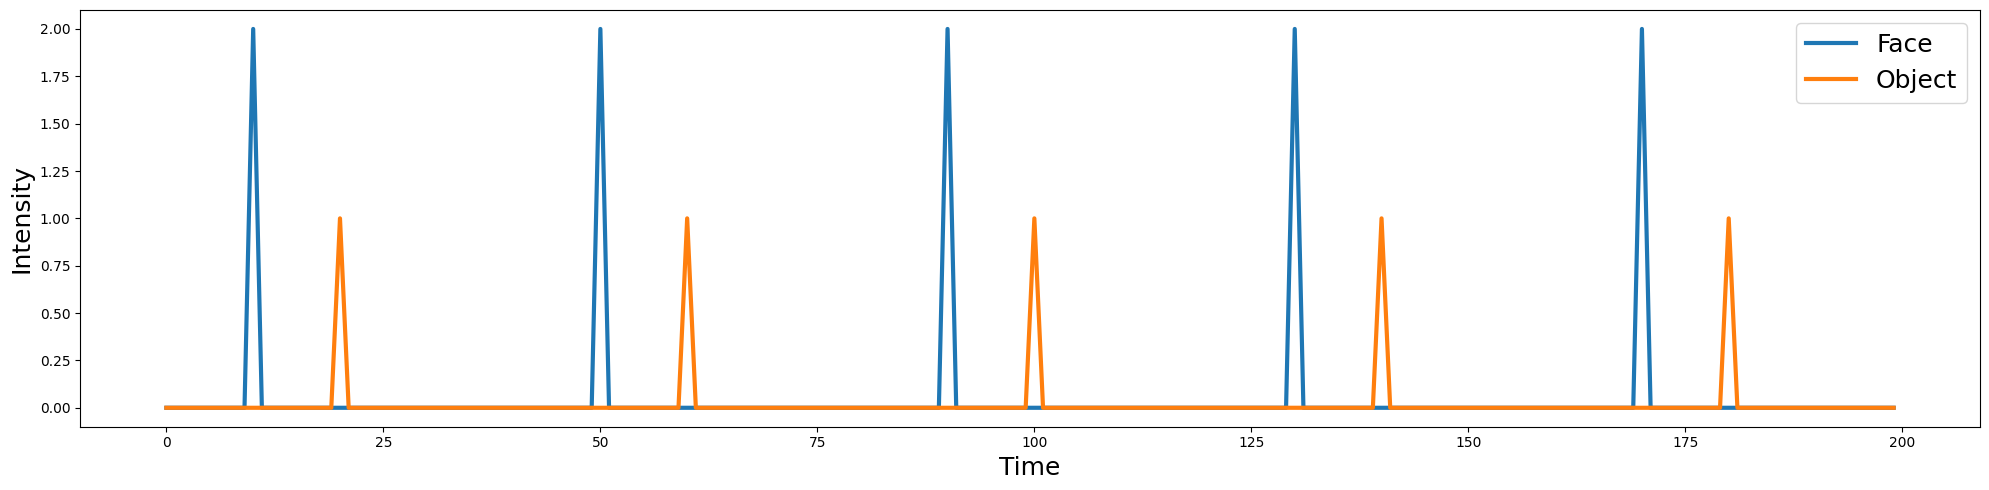

In [98]:
face_intensity=2
object_intensity=1
n_tr = 200
n_trial = 5
face = np.zeros(n_tr)
face[np.arange(10, n_tr, int(n_tr/n_trial))] = face_intensity
obj = np.zeros(n_tr)
obj[np.arange(20, n_tr, int(n_tr/n_trial))] = object_intensity
voxel = np.vstack([face,obj]).T # stack arrays vertically (new array's 1st axis dimension is larger 
# each previous array added as new rows(rows))

plot_timeseries(voxel, labels=['Face', 'Object'])

Text(0.5, 0, 'Time')

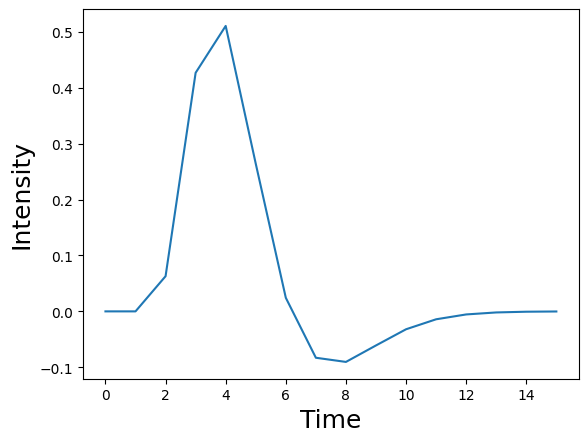

In [99]:
# the hemodynamic response function 
tr = 2
hrf=glover_hrf(tr, oversampling=1)
plt.plot(hrf)
plt.ylabel('Intensity', fontsize=18)
plt.xlabel('Time', fontsize=18)

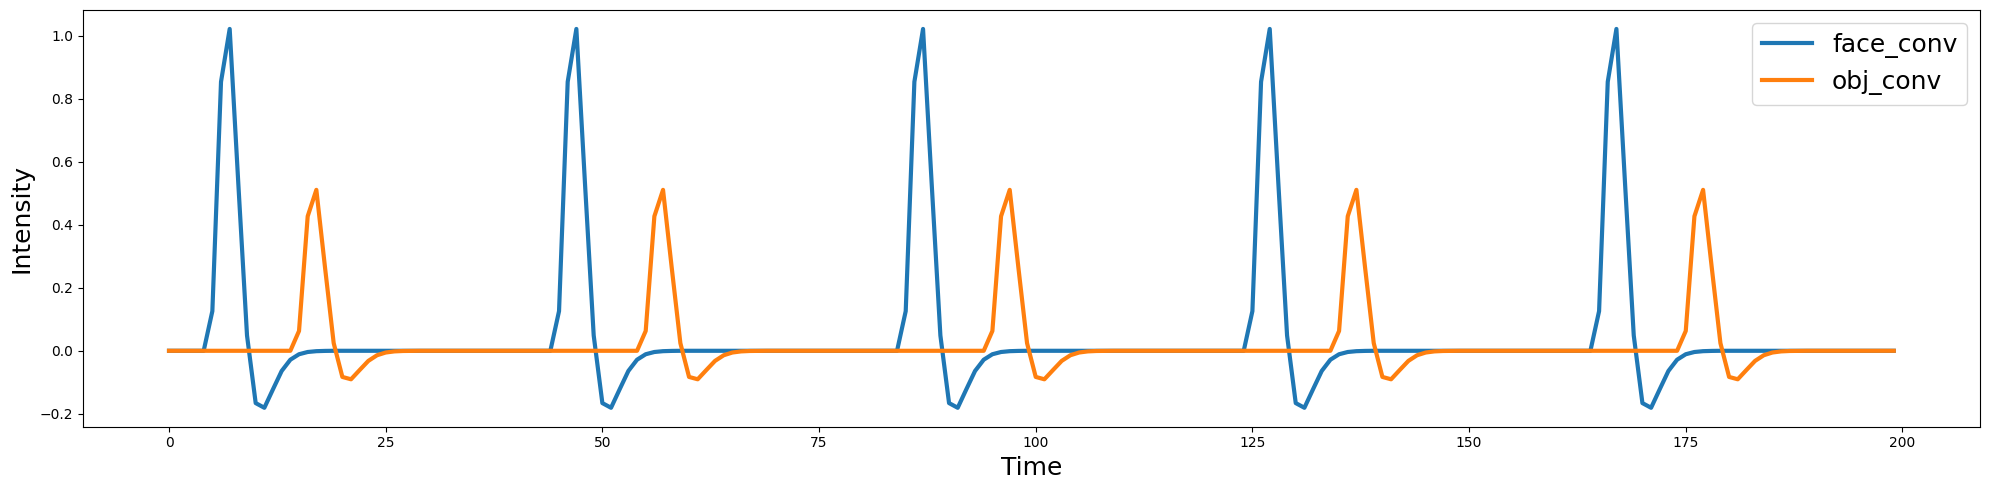

In [100]:
# convolve the actual data with the hrf
face_conv=np.convolve(face,hrf, mode="same") #mode save ensures same length for everything
obj_conv=np.convolve(obj, hrf, mode="same")
voxel_conv=np.vstack([face_conv,obj_conv]).T
plot_timeseries(voxel_conv,labels=["face_conv","obj_conv"])

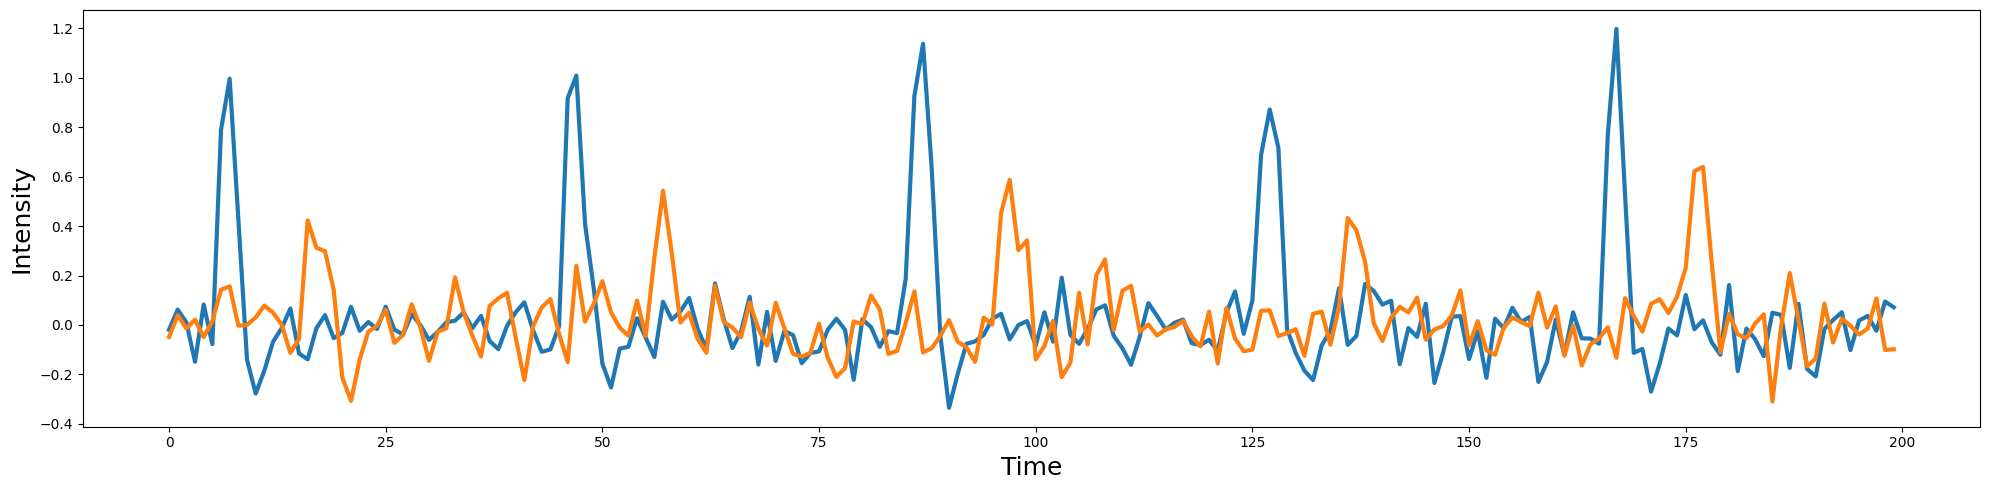

In [101]:
#adding noise
sigma=0.1
epsilon=sigma*np.random.randn(n_tr,2) #matrix with n_tr rows, 2 columns
voxel_conv_noise=voxel_conv+epsilon
plot_timeseries(voxel_conv_noise)


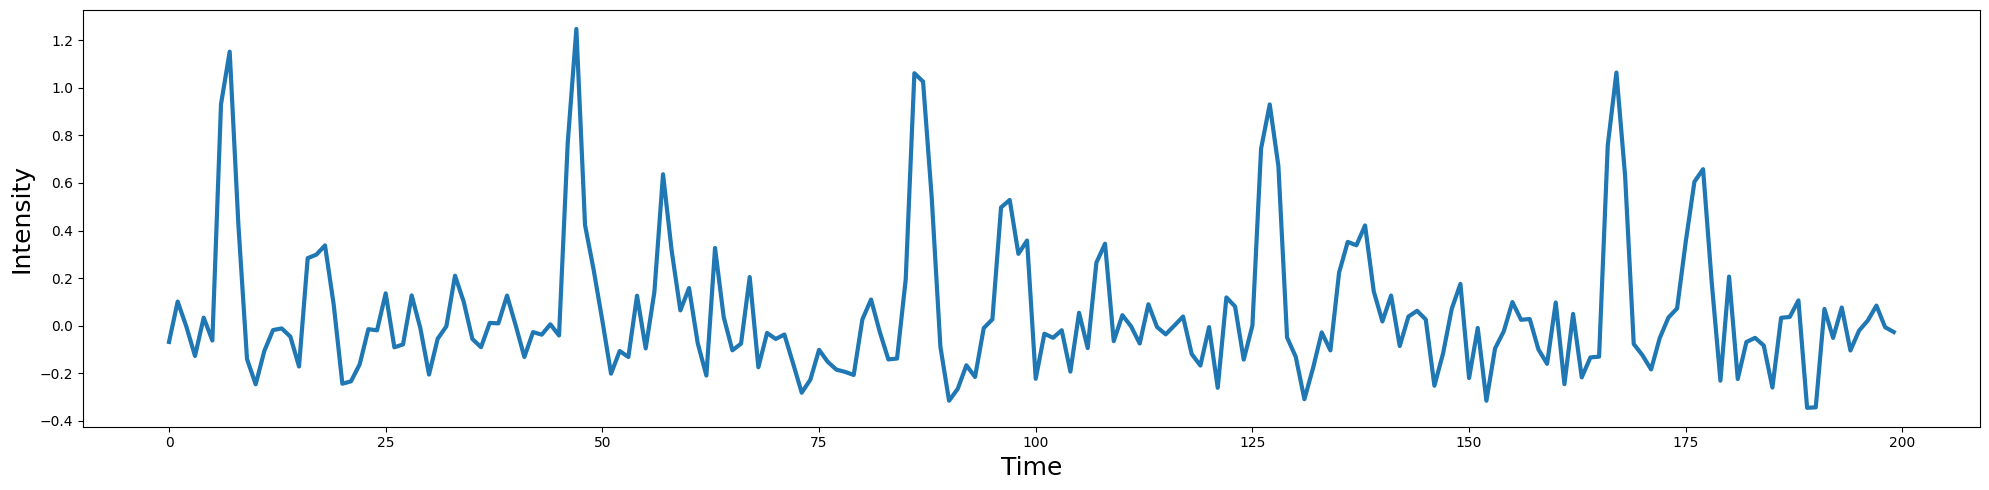

In [102]:
# remember, one signal represents face activation, the other object. In a bold signal, we wouldn't see two separate
# we see one activity that conscitutes many underlying activities. Add the waves 
# Y is our simulated voxel timeseries
Y=voxel_conv_noise.sum(axis=1) #sum columns 
plot_timeseries(Y)

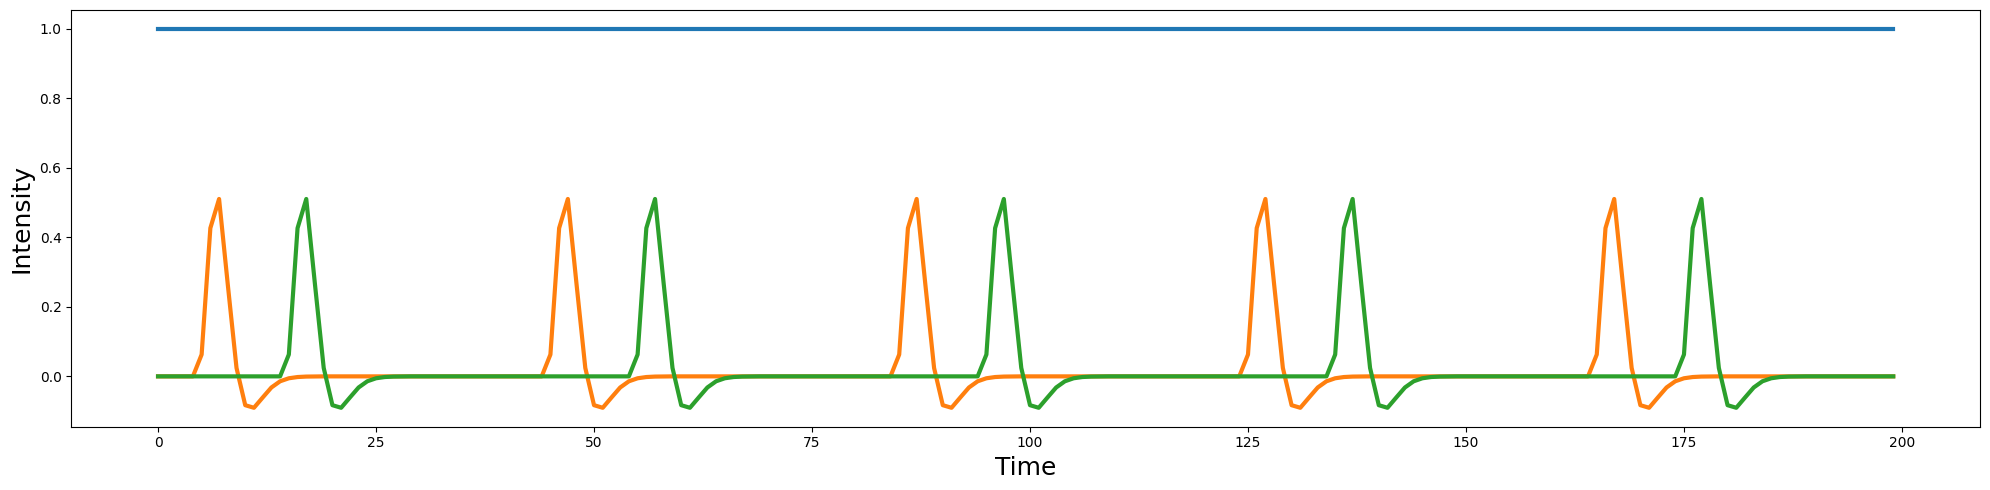

In [103]:
# now we have a signla that constitutes multiple underlying signals (that we aren't supposed to know of)
# lets design a design matrix, and check if GLM can recover original signal
#  Y = XB + e

#intercept
intercept=np.ones(n_tr)
face=np.zeros(n_tr)
face[np.arange(10,n_tr,int(n_tr/n_trial))]=1 # we don't know the intensity of activation in brain, so in design matrix, all coefficients are constat  
obj = np.zeros(n_tr)
obj[np.arange(20, n_tr, int(n_tr/n_trial))] = 1
# print(face_conv.shape)
# X is our design matrix! modeling all predictors
X = np.vstack([intercept, np.convolve(face, hrf, mode='same'), np.convolve(obj, hrf, mode='same')]).T
plot_timeseries(X)

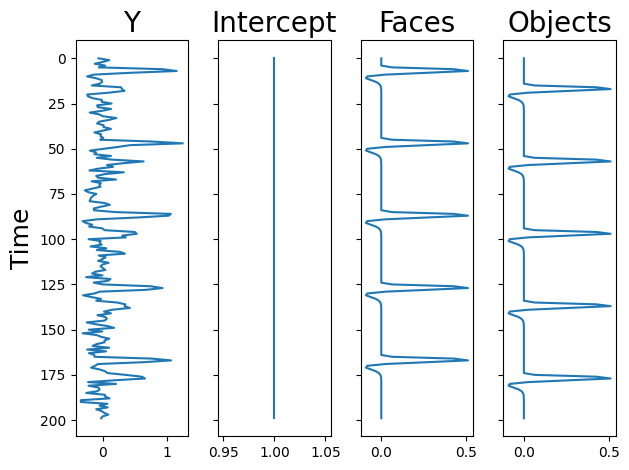

In [104]:
# model:
# Voxel = B_0 * intercept + B_1 * face_conv + B_2 * obj_conv + e
# lets invert the axis and plot subplots (getting closer to design matrix)
f,a=plt.subplots(ncols=4, sharey=True)
a[0].plot(np.expand_dims(Y,axis=1),range(len(Y)))
a[1].plot(X[:,0],range(len(Y)))
a[2].plot(X[:,1],range(len(Y)))
a[3].plot(X[:,2],range(len(Y)))
a[0].set_ylabel('Time', fontsize=18)
a[0].set_title('Y', fontsize=20)
a[1].set_title('Intercept', fontsize=20)
a[2].set_title('Faces', fontsize=20)
a[3].set_title('Objects', fontsize=20)
plt.gca().invert_yaxis()
plt.tight_layout()

beta Faces - beta Objects: 1.1


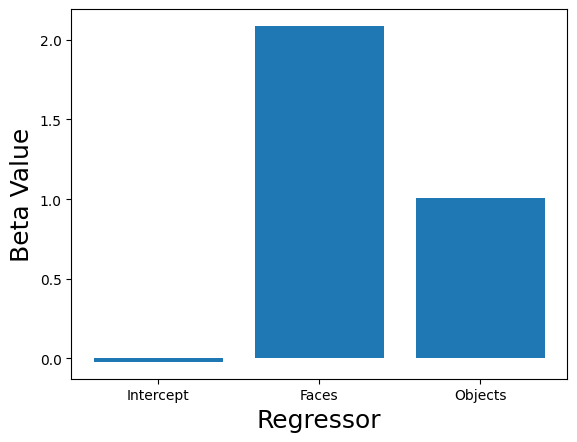

In [105]:
# returns estimate Beta
def ols_estimator(X, Y):
    return np.dot(np.dot(np.linalg.pinv(np.dot(X.T, X)), X.T), Y)

beta = ols_estimator(X, Y)

plt.bar(['Intercept','Faces', 'Objects'], beta)
plt.xlabel('Regressor', fontsize=18)
plt.ylabel('Beta Value', fontsize=18)

print(f'beta Faces - beta Objects: {beta[1]-beta[2]:.2}')

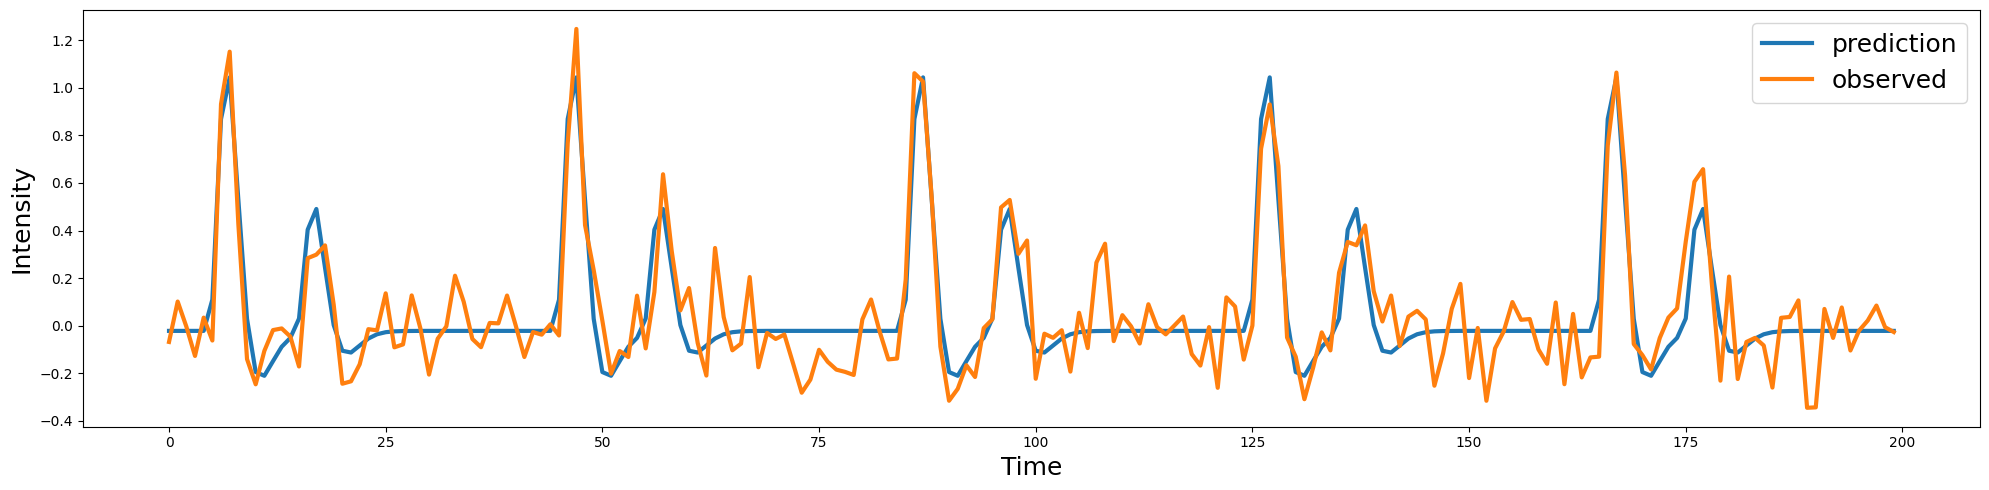

In [113]:
predicted_y=np.dot(X,beta)
predicted_ts=np.vstack([predicted_y,Y]).T
plot_timeseries(predicted_ts, labels=["prediction","observed"])
plt.show()

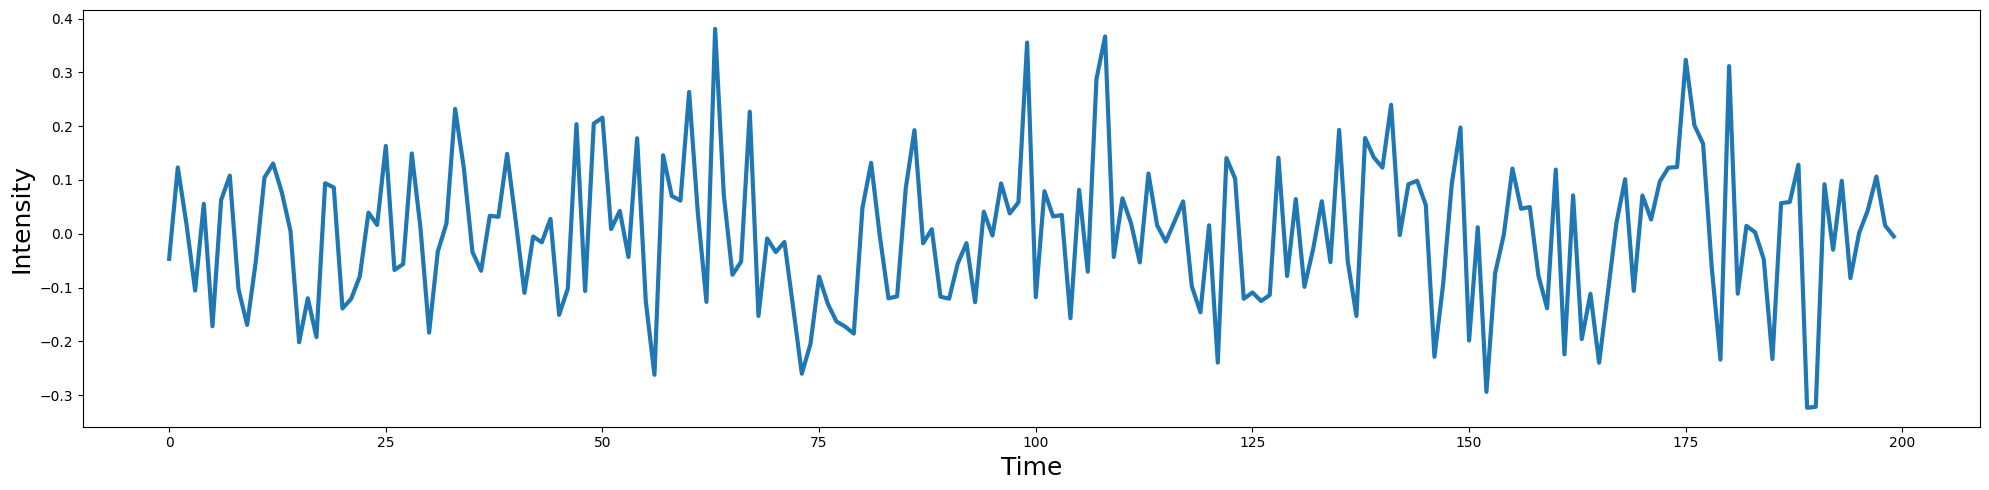

In [111]:
residual=Y-np.dot(X,beta)
plot_timeseries(residual)
plt.show()

standard error: 0.13450248043588792


(array([ 5., 13., 26., 35., 37., 41., 24., 12.,  2.,  5.]),
 array([-0.32325179, -0.25286345, -0.1824751 , -0.11208676, -0.04169841,
         0.02868994,  0.09907828,  0.16946663,  0.23985498,  0.31024332,
         0.38063167]),
 <BarContainer object of 10 artists>)

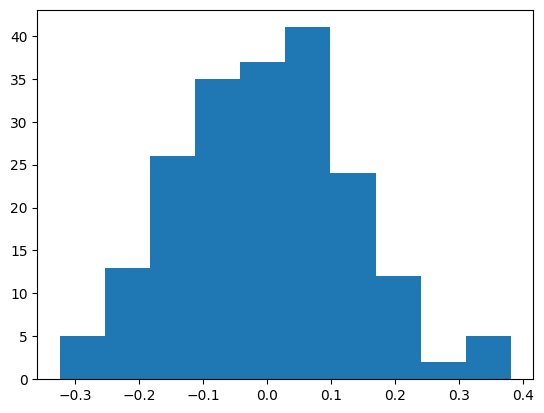

In [112]:
standard_error=np.std(residual)
print(f"standard error: {standard_error}")
plt.hist(residual)

In [ ]:
# explained variance
def r_square(Y, predicted_y):
    SS_total = np.sum((Y - np.mean(Y))**2)
    SS_residual = np.sum((Y - predicted_y)**2)
    return 1-(SS_residual/SS_total)

print(f"R^2: {r_square(Y, predicted_y):.2}")

R^2: 0.78
